### module

In [1]:
import data_processor as dp
from PIWON import HybridModel 

In [2]:

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error, root_mean_squared_error
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

import scipy.special
import scipy

import time
import pickle
import warnings
import os
import glob
import random
from itertools import chain, combinations
import copy
import importlib

import torch
import shap

In [3]:
import statsmodels.api as sa
import statsmodels.formula.api as sfa
import scikit_posthocs as sp

In [12]:
random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42)
cm=1/2.54

### curve

In [8]:
path=glob.glob('checkpoint/v2_*.pkl') 
path

['checkpoint\\v2_seed_0_Oct19.pkl',
 'checkpoint\\v2_seed_1_Oct19.pkl',
 'checkpoint\\v2_seed_2_Oct19.pkl',
 'checkpoint\\v2_seed_3_Oct19.pkl',
 'checkpoint\\v2_seed_4_Oct19.pkl']

In [9]:
all_dfs = []
for p in path:
    with open(p, 'rb') as f:
        train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
        df_1 = pd.DataFrame({'Loss': train_losses, 'Label': 'Train', 'Epoch': range(len(train_losses))})
        df_2 = pd.DataFrame({'Loss': valid_losses, 'Label': 'Valid', 'Epoch': range(len(valid_losses))})
        df_3 = pd.DataFrame({'Loss': test_losses, 'Label': 'Test', 'Epoch': range(len(test_losses))})
        df = pd.concat([df_1, df_2, df_3])
    all_dfs.append(df)
all_dfs_concat = pd.concat(all_dfs, ignore_index=True)

In [10]:
all_dfs_concat

,Loss,Label,Epoch
0,6.741553,Train,0
1,6.106320,Train,1
2,5.523856,Train,2
3,5.021090,Train,3
4,4.565425,Train,4
...,...,...,...
5995,0.649274,Test,395
5996,0.645163,Test,396
5997,0.636919,Test,397
5998,0.636568,Test,398


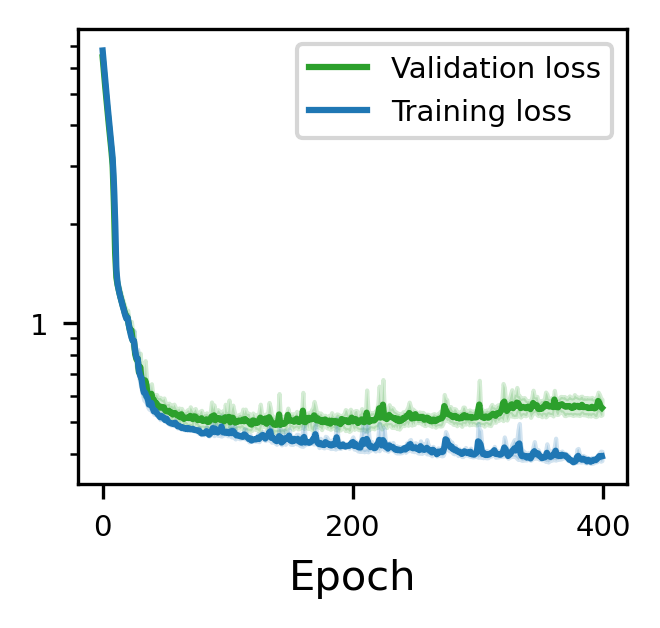

In [13]:

fig, ax = plt.subplots(figsize=(6*cm, 5*cm), dpi=300)


sns.lineplot(data=all_dfs_concat[all_dfs_concat['Label']=='Valid'], x="Epoch", y="Loss", color = 'C2', errorbar=('ci', 95), label = 'Validation loss' )
sns.lineplot(data=all_dfs_concat[all_dfs_concat['Label']=='Train'], x="Epoch", y="Loss", color = 'C0', errorbar=('ci', 95), label = 'Training loss' )

plt.legend(frameon= True, fontsize = 7, )

#plt.legend()
plt.yscale('log')
# plt.ylim([0.03,0.8])
plt.xlabel('Epoch', fontsize = 10)
plt.xticks(fontsize = 7)
#plt.yticks([1e-3,1e-2], fontsize = 8)
ax.set(ylabel=None)
plt.yticks([1],[1],fontsize = 7)
# plt.title('b) Traing curve Loss/MSE', fontsize = 10, loc = 'left')
plt.show()

### performance comparison

#### hybrid

In [14]:
hidden_size = 256
input_size = 18
dropout = 0.1

net = HybridModel(input_size, hidden_size, n_layers = 2, dropout = 0)

In [15]:
train_set = pd.read_csv(r'data/train_set.csv',index_col=0)
test_set = pd.read_csv(r'data/test_set.csv',index_col=0)

train_loader = dp.data_loader(train_set, batch_size = train_set.shape[0])
test_loader = dp.data_loader(test_set, batch_size = test_set.shape[0])

In [16]:
train_res = pd.DataFrame()
test_res = pd.DataFrame()
for s,p in enumerate(path):
    with open(p, 'rb') as f:
        train_losses, valid_losses,test_losses, best_model_state = pickle.load(f)
        net.load_state_dict(best_model_state)
        net.eval()
        net.to(device)
        
        data, label = [x.to(device) for x in next(iter(train_loader))]
    
        with torch.no_grad():
            runoff, total_runoff, load_record = net(data)
            total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

            pred = (((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).cpu()).numpy()
            true = (label[:,0].cpu()).numpy()
        
        train_res['Label'] = true
        train_res[s] = pred


        data, label = [x.to(device) for x in next(iter(test_loader))]
        with torch.no_grad():
            runoff, total_runoff, load_record = net(data)
            total_runoff = torch.where(total_runoff == 0, torch.finfo().tiny, total_runoff)

            pred = (((load_record[:,0] - load_record[:,-1])/torch.flatten(total_runoff)).cpu()).numpy()
            true = (label[:,0].cpu()).numpy()

        test_res['Label'] = true
        test_res[s] = pred


In [19]:
train_res

,Label,0,1,2,3,4
0,2.197225,2.378154,2.834225,2.480241,2.354227,2.217104
1,3.555348,3.104944,3.288923,3.386188,2.929867,3.035772
2,5.117994,4.950648,5.144592,5.017034,5.009930,4.837302
3,3.637586,3.940334,3.895669,3.912276,3.956710,3.931408
4,3.931826,4.624227,4.608559,4.771013,4.722068,4.427178
...,...,...,...,...,...,...
6728,6.255750,5.839752,6.109686,5.912492,6.080021,6.205244
6729,4.652245,3.705614,3.979665,3.818409,3.905769,3.827375
6730,4.204693,4.542335,4.456009,4.477031,4.516914,4.452209
6731,2.772589,3.782703,3.686670,3.901844,3.845109,3.873511


In [20]:
train_metrics = pd.DataFrame(columns=['R2', 'RMSE', 'MAPE'])
for s in range(len(path)):
    r2 = r2_score(train_res['Label'], train_res[s])
    rmse = root_mean_squared_error(train_res['Label'], train_res[s])
    mape = mean_absolute_percentage_error(train_res['Label'], train_res[s])
    train_metrics.loc[s] = [r2, rmse, mape]

# print the mean R2 with 2 decimal places
print(f"R2: {train_metrics['R2'].mean():.2f}±{train_metrics['R2'].std():.2f}")
print(f"RMSE: {train_metrics['RMSE'].mean():.2f}±{train_metrics['RMSE'].std():.2f}")
print(f"MAPE: {train_metrics['MAPE'].mean():.2f}±{train_metrics['MAPE'].std():.2f}")

R2: 0.69±0.01
RMSE: 0.65±0.01
MAPE: 0.13±0.00


In [21]:

test_metrics = pd.DataFrame(columns=['R2', 'RMSE', 'MAPE'])
for s in range(len(path)):
    r2 = r2_score(test_res['Label'], test_res[s])
    rmse = root_mean_squared_error(test_res['Label'], test_res[s])
    mape = mean_absolute_percentage_error(test_res['Label'], test_res[s])
    test_metrics.loc[s] = [r2, rmse, mape]

# print the mean R2 with 2 decimal places
print(f"R2: {test_metrics['R2'].mean():.2f}±{test_metrics['R2'].std():.3f}")
print(f"RMSE: {test_metrics['RMSE'].mean():.2f}±{test_metrics['RMSE'].std():.3f}")
print(f"MAPE: {test_metrics['MAPE'].mean():.2f}±{test_metrics['MAPE'].std():.3f}")


R2: 0.65±0.007
RMSE: 0.69±0.007
MAPE: 0.13±0.002


In [22]:
GA = train_metrics['RMSE']/test_metrics['RMSE']
print(f"GA: {GA.mean():.2f}±{GA.std():.3f}")


GA: 0.94±0.016


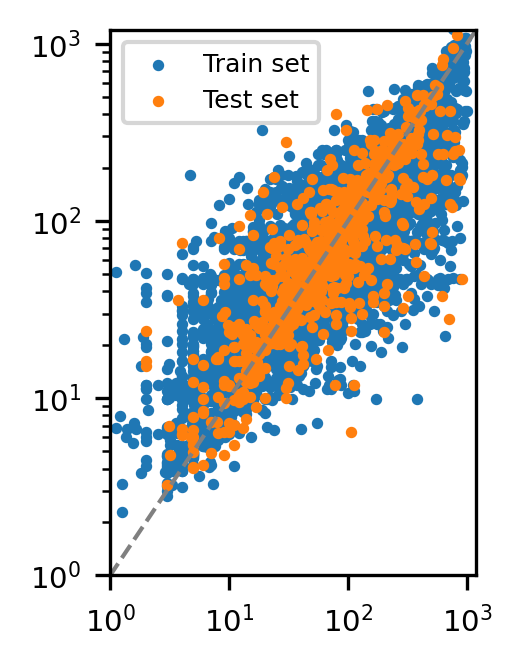

In [24]:
cm=2.54

plt.figure(figsize = [4/cm, 6/cm], dpi = 300)

pred = train_res.iloc[:,1:].mean(axis=1)
true = train_res['Label']

pred = np.expm1(pred)
true = np.expm1(true)
plt.scatter(true, pred, s = 3, label = 'Train set',)
#plt.title('Model '+ str(i) + ' on train set')

pred = test_res.iloc[:,1:].mean(axis=1)
true = test_res['Label']

pred = np.expm1(pred)
true = np.expm1(true)

plt.scatter(true, pred, s = 3, label = 'Test set', )
#plt.title('Model '+ str(i) + ' on test set')
#plt.xlabel('True')
#plt.ylabel('Pred')
#plt.text(2,7,str(round(r2_score(true, pred),4)))


plt.plot([1e-1,2e3],[1e-1,2e3],c = 'gray', ls = '--', alpha = 1, lw = 1)
plt.xlim([1e0,1.2e3])
plt.ylim([1e0,1.2e3])


plt.yscale('log')
plt.xscale('log')

plt.legend(fontsize = 6)
plt.yticks(fontsize = 7)
plt.xticks([1e0,1e1,1e2,1e3],fontsize = 7)
# plt.title('b) Traing curve Loss/MSE', fontsize = 10, loc = 'left')
plt.show()



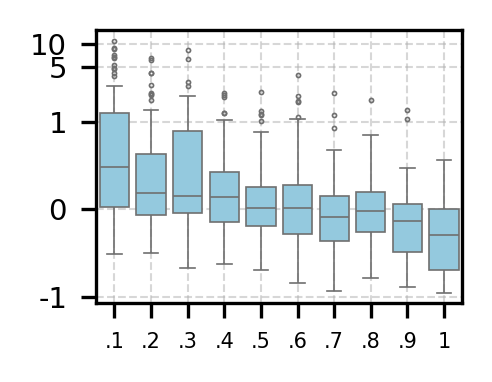

In [25]:
df_temp = pd.DataFrame({
    'ground_truth': true,
    'error': (pred - true)/true
})
df_temp['percentile_bin'] = pd.qcut(df_temp['ground_truth'], q=10, labels=['.1','.2','.3','.4','.5','.6','.7','.8','.9','1'])

fig, ax = plt.subplots(figsize=(4/cm, 3/cm), dpi=300)
sns.boxplot(data=df_temp, x='percentile_bin', y='error',  fliersize = 0.4, linewidth=0.4, color='skyblue')
plt.xlabel(None, fontsize = 7)
plt.ylabel(None, fontsize = 7)
# plt.title(label_dict[model_name], loc='left', fontsize = 9)
plt.xticks(fontsize = 5)

plt.yscale('symlog', linthresh=1)

plt.yticks([-1,0,1,5,10,20],[-1,0,1,5,10,20],fontsize = 7)
plt.ylim(-1.2, 15)

plt.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
# plt.tight_layout()
plt.show()

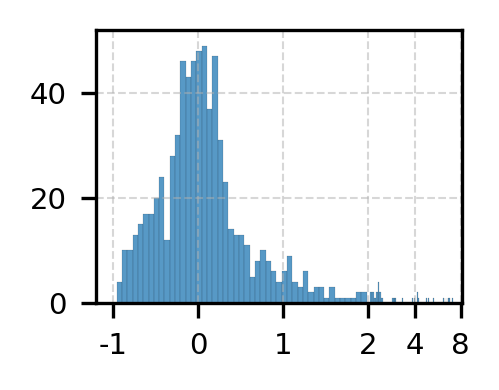

In [26]:
fig, ax = plt.subplots(figsize=(4/cm, 3/cm), dpi=300)

sns.histplot(data=df_temp, x="error",bins=300, )

plt.xlabel(None, fontsize = 7)
plt.ylabel(None, fontsize = 7)

plt.xscale('symlog', )
plt.xticks([-1,0,1,2,4,8],[-1,0,1,2,4,8],fontsize = 7)
plt.yticks(fontsize = 7) 
plt.xlim(-1.2, 8.2)
plt.ylim(0, 52)
plt.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

plt.show()

#### others

In [28]:
with open('data/autogluon_res.pkl', 'rb') as f:
    autogluon_res = pickle.load( f)

In [29]:
autogluon_res[0][0]

,Label,TabPFNv2_r181_BAG_L1,LightGBM_r33_BAG_L1,TabM_r49_BAG_L1,XGBoost_r40_BAG_L1,CatBoost_r10_BAG_L1
7305,2.197225,2.891488,3.000252,2.873219,3.038134,3.077915
6365,3.555348,4.172138,3.793061,3.821910,3.805929,3.779657
8896,5.117994,5.056149,5.047892,5.053607,5.098566,5.078784
1063,3.637586,3.879387,3.978101,3.971855,3.969992,3.979361
3882,3.931826,4.333435,4.090581,4.212045,4.167575,4.103965
...,...,...,...,...,...,...
6098,6.255750,4.910043,5.462431,5.263928,5.395486,5.494509
4124,4.652245,4.023710,3.979371,4.069493,3.928166,4.040517
2089,4.204693,4.391947,4.270496,4.312728,4.195779,4.265777
3456,2.772589,3.909827,3.785581,3.716927,3.829540,3.800427


In [30]:
model_to_use = ['XGBoost_r40_BAG_L1','LightGBM_r33_BAG_L1','CatBoost_r10_BAG_L1', 'TabM_r49_BAG_L1','TabPFNv2_r181_BAG_L1',]
autogluon_res_dict = {}
autogluon_metrics = {}
for m in model_to_use:
    print(m)
    train_res = pd.DataFrame()
    test_res = pd.DataFrame()
    autogluon_metrics[m] = pd.DataFrame(columns=['R2', 'RMSE', 'MAPE','Dataset'])
    train_res['Label'] = autogluon_res[0][0]['Label']
    test_res['Label'] = autogluon_res[0][1]['Label']
    for s in range(5):
        train_res[s] = autogluon_res[s][0][m]
        r2 = r2_score(train_res['Label'], train_res[s])
        rmse = root_mean_squared_error(train_res['Label'], train_res[s])
        mape = mean_absolute_percentage_error(train_res['Label'], train_res[s])
        autogluon_metrics[m].loc[2*s] = [r2, rmse, mape, 'Train']

        test_res[s] = autogluon_res[s][1][m]
        r2 = r2_score(test_res['Label'], test_res[s])
        rmse = root_mean_squared_error(test_res['Label'], test_res[s])
        mape = mean_absolute_percentage_error(test_res['Label'], test_res[s])
        autogluon_metrics[m].loc[2*s+1] = [r2, rmse, mape, 'Test']
    autogluon_res_dict[m] = [train_res, test_res]

    print('Train', end="  ")
    temp = autogluon_metrics[m][autogluon_metrics[m]['Dataset']=='Train']
    print(f"R2: {temp['R2'].mean():.2f}±{temp['R2'].std():.3f}", end="  ") # donot break the line
    print(f"RMSE: {temp['RMSE'].mean():.2f}±{temp['RMSE'].std():.3f}", end="  ")
    print(f"MAPE: {temp['MAPE'].mean():.2f}±{temp['MAPE'].std():.3f}",)
    print('Test', end="  ")
    temp = autogluon_metrics[m][autogluon_metrics[m]['Dataset']=='Test']
    print(f"R2: {temp['R2'].mean():.2f}±{temp['R2'].std():.3f}", end="  ")
    print(f"RMSE: {temp['RMSE'].mean():.2f}±{temp['RMSE'].std():.3f}", end="  ")
    print(f"MAPE: {temp['MAPE'].mean():.2f}±{temp['MAPE'].std():.3f}", )          
    print('GA', end="  ")
    GA = autogluon_metrics[m][autogluon_metrics[m]['Dataset']=='Train']['RMSE'].values/autogluon_metrics[m][autogluon_metrics[m]['Dataset']=='Test']['RMSE'].values
    print(f"{GA.mean():.2f}±{GA.std():.3f}")
    print()



XGBoost_r40_BAG_L1
Train  R2: 0.51±0.005  RMSE: 0.81±0.004  MAPE: 0.18±0.001
Test  R2: 0.32±0.001  RMSE: 0.95±0.000  MAPE: 0.21±0.000
GA  0.85±0.004

LightGBM_r33_BAG_L1
Train  R2: 0.56±0.009  RMSE: 0.77±0.007  MAPE: 0.17±0.002
Test  R2: 0.32±0.001  RMSE: 0.95±0.000  MAPE: 0.21±0.000
GA  0.81±0.007

CatBoost_r10_BAG_L1
Train  R2: 0.53±0.004  RMSE: 0.80±0.003  MAPE: 0.18±0.001
Test  R2: 0.31±0.001  RMSE: 0.96±0.001  MAPE: 0.21±0.000
GA  0.83±0.003

TabM_r49_BAG_L1
Train  R2: 0.51±0.009  RMSE: 0.81±0.008  MAPE: 0.18±0.003
Test  R2: 0.31±0.002  RMSE: 0.96±0.002  MAPE: 0.21±0.000
GA  0.84±0.007

TabPFNv2_r181_BAG_L1
Train  R2: 0.47±0.000  RMSE: 0.84±0.000  MAPE: 0.19±0.000
Test  R2: 0.33±0.000  RMSE: 0.95±0.000  MAPE: 0.21±0.000
GA  0.89±0.000



XGBoost_r40_BAG_L1


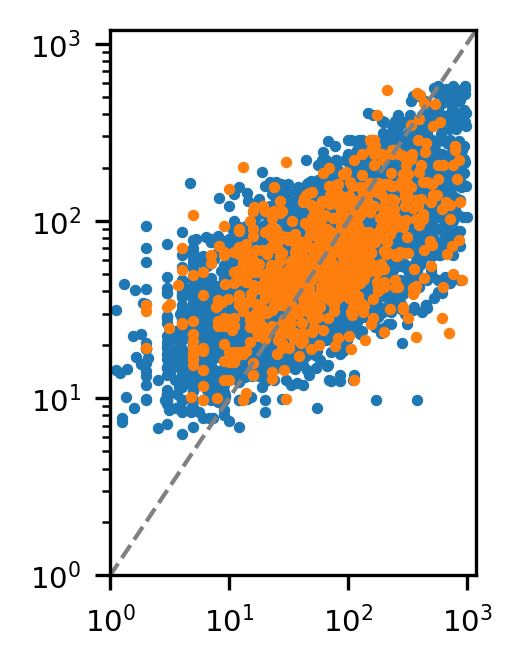

LightGBM_r33_BAG_L1


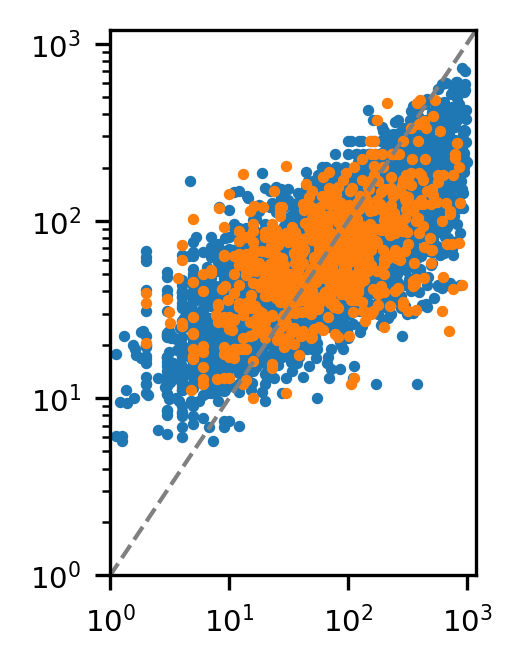

CatBoost_r10_BAG_L1


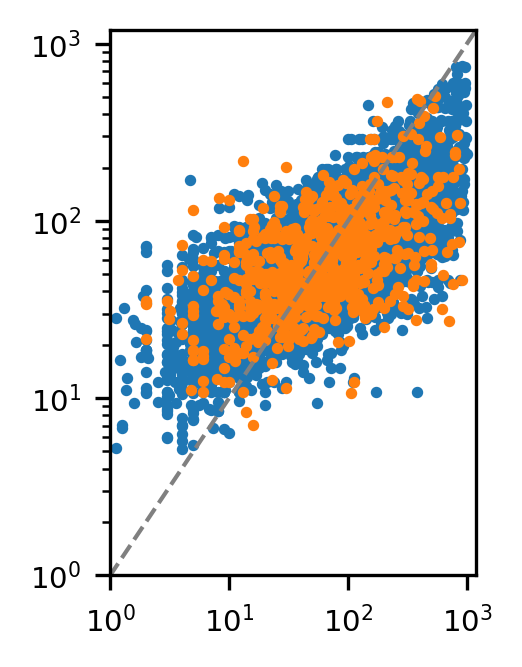

TabM_r49_BAG_L1


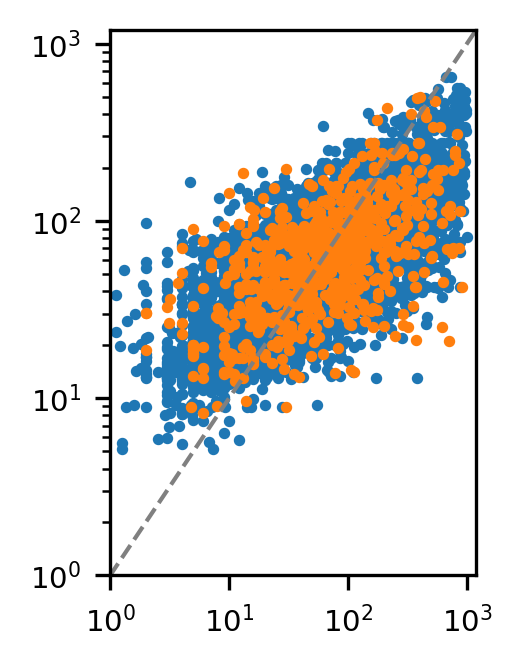

TabPFNv2_r181_BAG_L1


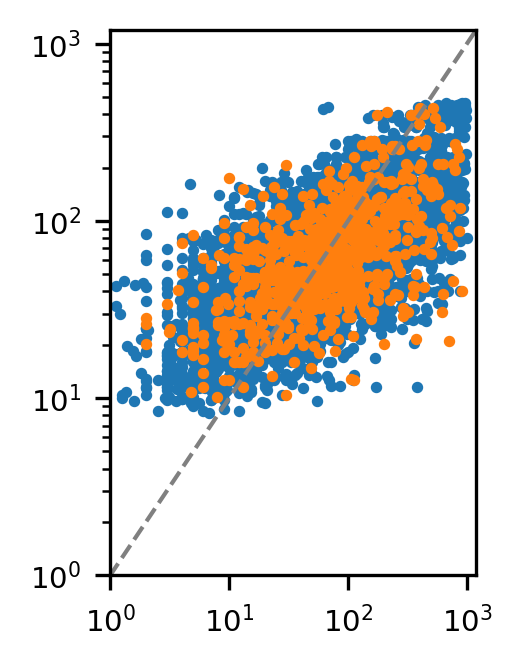

In [32]:
for m in model_to_use:
    train_res = autogluon_res_dict[m][0]
    test_res = autogluon_res_dict[m][1]
    print(m)
    cm=2.54

    plt.figure(figsize = [4/cm, 6/cm], dpi = 300)

    pred = train_res.iloc[:,1:].mean(axis=1)
    true = train_res['Label']

    pred = np.expm1(pred)
    true = np.expm1(true)
    plt.scatter(true, pred, s = 3, label = 'Train set',)
    #plt.title('Model '+ str(i) + ' on train set')

    pred = test_res.iloc[:,1:].mean(axis=1)
    true = test_res['Label']

    pred = np.expm1(pred)
    true = np.expm1(true)

    plt.scatter(true, pred, s = 3, label = 'Test set', )
    #plt.title('Model '+ str(i) + ' on test set')
    #plt.xlabel('True')
    #plt.ylabel('Pred')
    #plt.text(2,7,str(round(r2_score(true, pred),4)))


    plt.plot([1e-1,2e3],[1e-1,2e3],c = 'gray', ls = '--', alpha = 1, lw = 1)
    plt.xlim([1e0,1.2e3])
    plt.ylim([1e0,1.2e3])


    plt.yscale('log')
    plt.xscale('log')

    # plt.legend(fontsize = 6)
    plt.yticks(fontsize = 7)
    plt.xticks([1e0,1e1,1e2,1e3],fontsize = 7)
    # plt.title('b) Traing curve Loss/MSE', fontsize = 10, loc = 'left')
    plt.show()



XGBoost_r40_BAG_L1


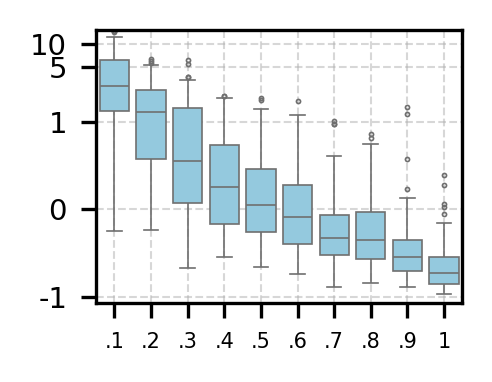

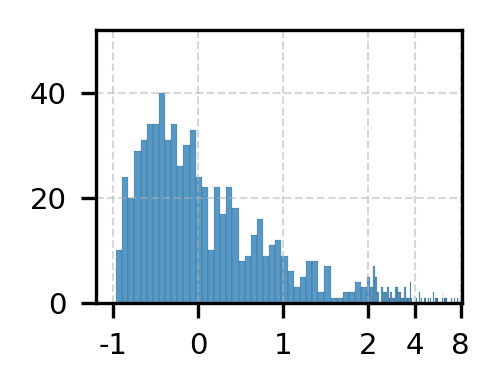

LightGBM_r33_BAG_L1


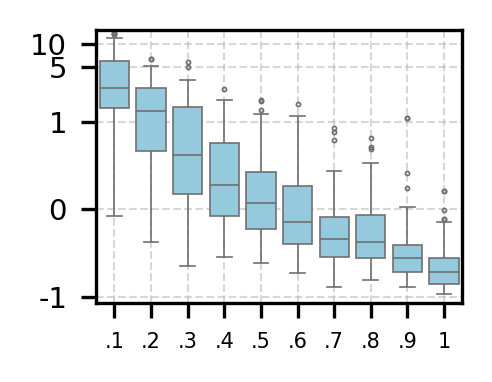

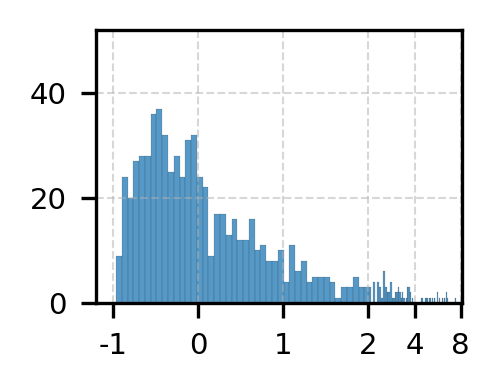

CatBoost_r10_BAG_L1


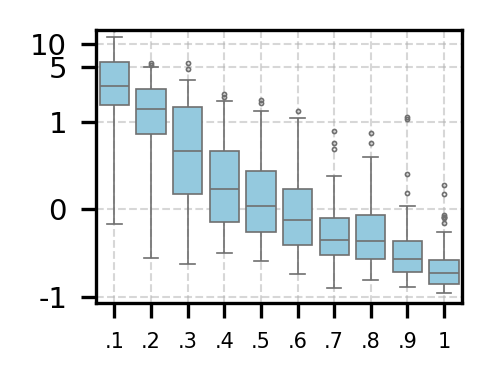

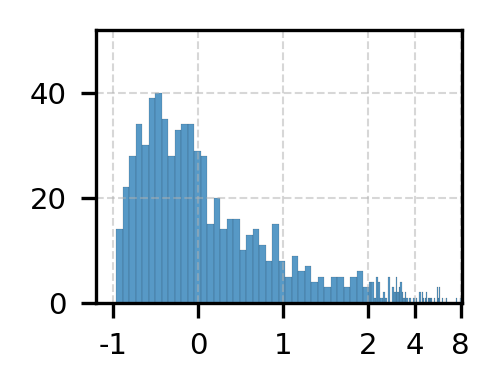

TabM_r49_BAG_L1


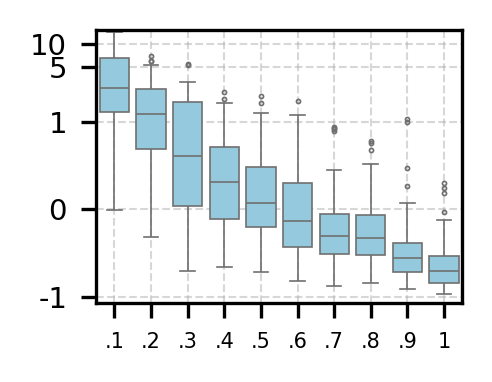

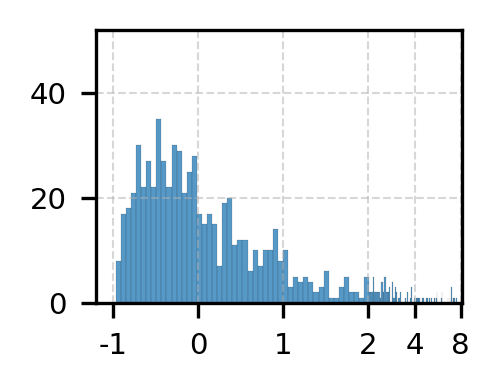

TabPFNv2_r181_BAG_L1


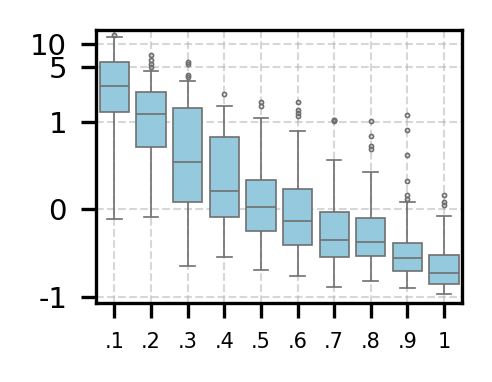

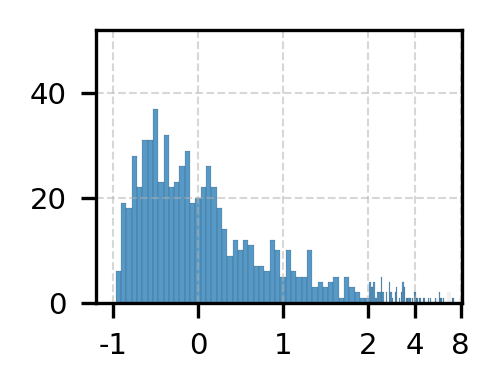

In [478]:
for m in model_to_use:
    train_res = autogluon_res_dict[m][0]
    test_res = autogluon_res_dict[m][1]
    print(m)
    cm=2.54

    pred = test_res.iloc[:,1:].mean(axis=1)
    true = test_res['Label']

    pred = np.expm1(pred)
    true = np.expm1(true)



    df_temp = pd.DataFrame({
        'ground_truth': true,
        'error': (pred - true)/true
    })
    df_temp['percentile_bin'] = pd.qcut(df_temp['ground_truth'], q=10, labels=['.1','.2','.3','.4','.5','.6','.7','.8','.9','1'])

    fig, ax = plt.subplots(figsize=(4/cm, 3/cm), dpi=300)
    sns.boxplot(data=df_temp, x='percentile_bin', y='error',  fliersize = 0.4, linewidth=0.4, color='skyblue')
    plt.xlabel(None, fontsize = 7)
    plt.ylabel(None, fontsize = 7)
    # plt.title(label_dict[model_name], loc='left', fontsize = 9)
    plt.xticks(fontsize = 5)

    plt.yscale('symlog', linthresh=1)

    plt.yticks([-1,0,1,5,10,20],[-1,0,1,5,10,20],fontsize = 7)
    plt.ylim(-1.2, 15)

    plt.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
    # plt.tight_layout()
    plt.show()


    fig, ax = plt.subplots(figsize=(4/cm, 3/cm), dpi=300)

    sns.histplot(data=df_temp, x="error",bins=300, )

    plt.xlabel(None, fontsize = 7)
    plt.ylabel(None, fontsize = 7)

    plt.xscale('symlog', )
    plt.xticks([-1,0,1,2,4,8],[-1,0,1,2,4,8],fontsize = 7)
    plt.yticks(fontsize = 7) 
    plt.xlim(-1.2, 8.2)
    plt.ylim(0, 52)
    plt.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)

    plt.show()
    

### practice comparison 

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def generate_event(event_type='first_flush'):
    t = np.arange(0, 240, 1)  # 100 minutes
    
    # Runoff (Q) - Bell shaped for both, maybe slightly skewed
    # Gamma-like shape: t^a * exp(-t/b)
    # Peak around t=30
    q_shape = (t / 30) ** 2 * np.exp(-t / 15)
    # Normalize and scale to get total volume around 25-30 mm
    # Current sum is approximate.
    q_norm = q_shape / np.sum(q_shape)
    total_runoff_mm = 30.0
    Q = q_norm * total_runoff_mm # mm/min
    
    # Concentration (C)
    if event_type == 'first_flush':
        # High at start, decays. Exponential decay.
        C = 500 * np.exp(-t / 10) + 20 # Base level 20 mg/L
    elif event_type == 'laging_flush':
        # Peak comes later. Gaussian peak.
        # Peak around t=50 (lagged behind runoff peak of 30)
        C = 400 * np.exp(-(t - 50)**2 / (2 * 10**2)) + 20
    
    return t, Q, C


In [49]:

def calculate_stats(t, Q, C, capacity_mm=10.0):
    dt = t[1] - t[0]
    total_vol = np.sum(Q) * dt
    mass_load = Q * C * dt # Mass per time step
    total_mass = np.sum(mass_load)
    
    # 1. Volume-Based (First Flush)
    # Take first N steps where cumulative Q <= capacity
    cum_Q = np.cumsum(Q) * dt
    # Find index where capacity is reached
    idx_vol = np.searchsorted(cum_Q, capacity_mm)
    # Handle partial step if needed, but for viz integer steps are fine if resolution is high
    # Let's be precise: exact fraction of last step?
    # For visualization "fill", mask is easier.
    vol_mask = cum_Q <= capacity_mm
    # If the first step > capacity (unlikely for 10mm), handle it.
    if not np.any(vol_mask) and capacity_mm > 0:
         vol_mask[0] = True # Take at least part of first
    
    mass_treated_vol = np.sum(mass_load[vol_mask])
    # Correction for the transition step where it exceeds 10mm
    # Calculate exact:
    idx_exceed = np.argmax(cum_Q > capacity_mm)
    if cum_Q[idx_exceed] > capacity_mm and idx_exceed > 0:
        # volume filled before this step
        vol_prev = cum_Q[idx_exceed-1]
        vol_needed = capacity_mm - vol_prev
        # Fraction of this step taken
        frac = vol_needed / (Q[idx_exceed] * dt)
        mass_treated_vol = np.sum(mass_load[:idx_exceed]) + mass_load[idx_exceed] * frac
        # For mask plotting, we usually just highlight the full bars for simplicity or do precise filling. 
        # I'll stick to full bars for the mask array for simplicity in bar coloring, 
        # but the ratio text will be precise.
    
    ratio_vol = mass_treated_vol / total_mass
    
    # 2. Quality-Based
    # Sort time steps by Concentration descending
    # Accumulate volume until capacity
    sorted_indices = np.argsort(C)[::-1]
    
    current_vol = 0
    qual_mask = np.zeros_like(t, dtype=bool)
    mass_treated_qual = 0
    
    for idx in sorted_indices:
        vol_step = Q[idx] * dt
        if current_vol + vol_step <= capacity_mm:
            current_vol += vol_step
            mass_treated_qual += mass_load[idx]
            qual_mask[idx] = True
        else:
            # Partial take?
            remaining = capacity_mm - current_vol
            if remaining > 0:
                frac = remaining / vol_step
                mass_treated_qual += mass_load[idx] * frac
                # For viz, maybe we don't fill this bar fully? 
                # Let's just mark it as part of the strategy.
                qual_mask[idx] = True 
            break
            
    ratio_qual = mass_treated_qual / total_mass
    
    return {
        'total_vol': total_vol,
        'total_mass': total_mass,
        'ratio_vol': ratio_vol,
        'ratio_qual': ratio_qual,
        'vol_mask': vol_mask,
        'qual_mask': qual_mask
    }


Total Volume: 15.00 mm, Total Mass: 2000.00 mg
Total Volume: 15.00 mm, Total Mass: 2000.03 mg


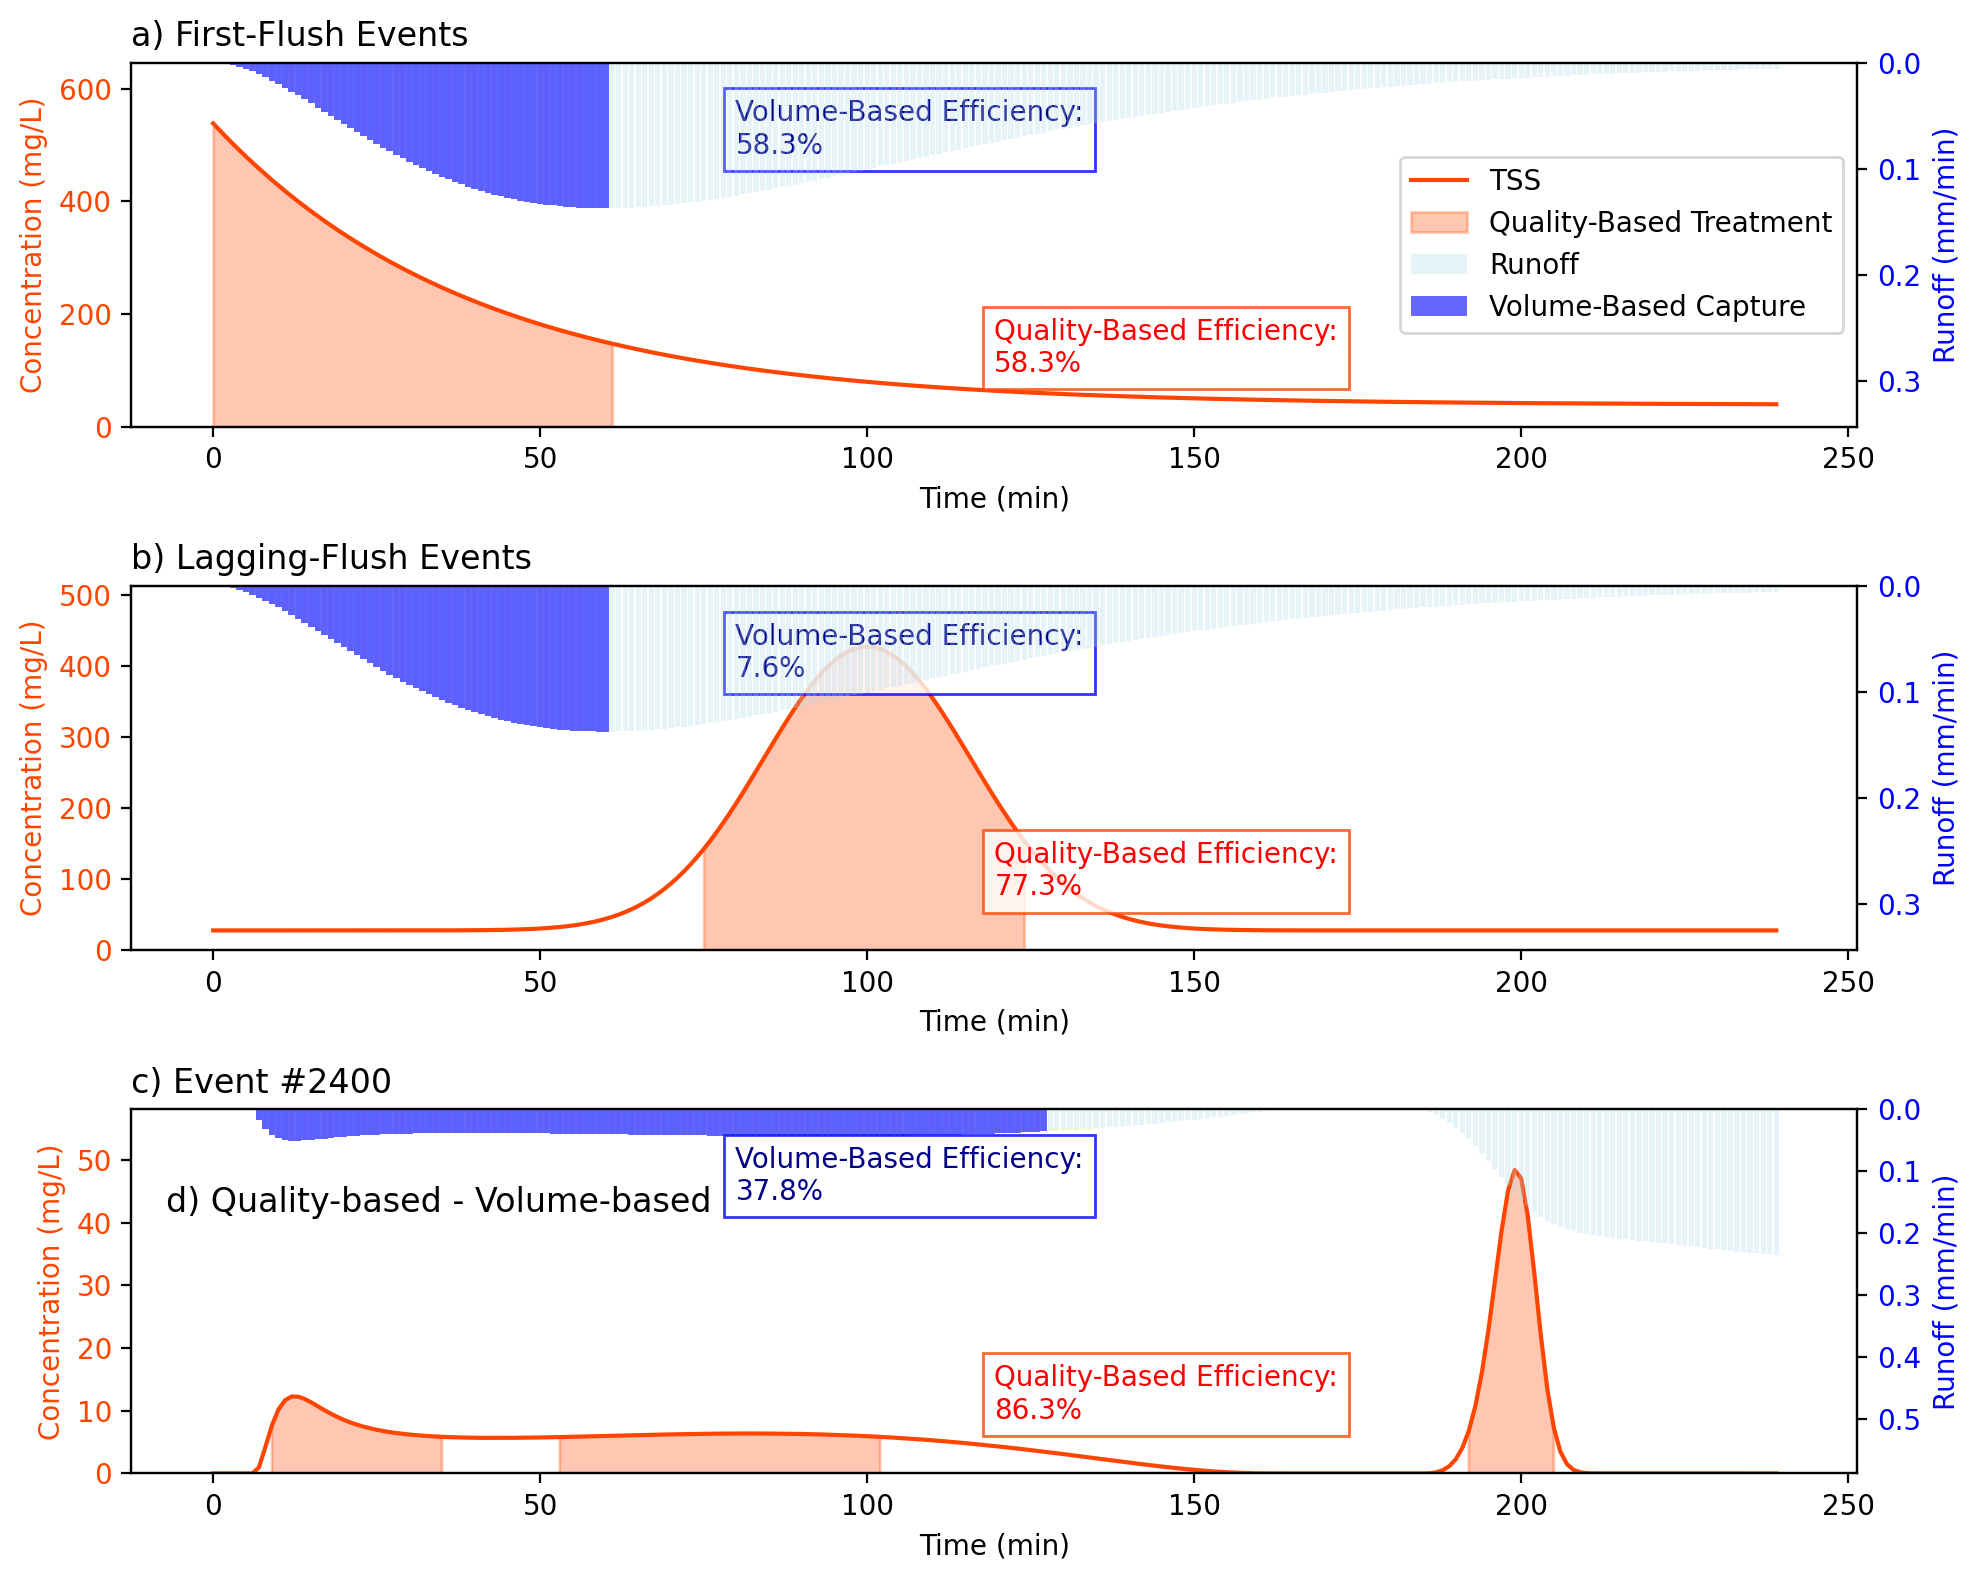

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def generate_event(event_type='first_flush'):
    t = np.arange(0, 240, 1)  # 100 minutes
    
    # Runoff (Q) - Bell shaped for both, maybe slightly skewed
    # Gamma-like shape: t^a * exp(-t/b)
    # Peak around t=60
    q_shape = (t / 60) ** 2 * np.exp(-t / 30)
    # Normalize and scale to get total volume around 25-30 mm
    # Current sum is approximate.
    q_norm = q_shape / np.sum(q_shape)
    total_runoff_mm = 15.0
    Q = q_norm * total_runoff_mm # mm/min
    
    # Concentration (C)
    if event_type == 'first_flush':
        # High at start, decays. Exponential decay.
        C = 500 * np.exp(-t / 40) + 38.73 # Base level 20 mg/L
    elif event_type == 'lagged_flush':
        # Peak comes later. Gaussian peak.
        # Peak around t=50 (lagged behind runoff peak of 60)
        C = 400 * np.exp(-(t - 100)**2 / (5 * 10**2)) + 27.74
    
    return t, Q, C

def calculate_stats(t, Q, C, capacity_mm=5.0):
    dt = t[1] - t[0]
    total_vol = np.sum(Q) * dt
    mass_load = Q * C * dt # Mass per time step
    total_mass = np.sum(mass_load)
    
    # 1. Volume-Based (First Flush)
    # Take first N steps where cumulative Q <= capacity
    cum_Q = np.cumsum(Q) * dt
    # Find index where capacity is reached
    idx_vol = np.searchsorted(cum_Q, capacity_mm)
    # Handle partial step if needed, but for viz integer steps are fine if resolution is high
    # Let's be precise: exact fraction of last step?
    # For visualization "fill", mask is easier.
    vol_mask = cum_Q <= capacity_mm
    # If the first step > capacity (unlikely for 10mm), handle it.
    if not np.any(vol_mask) and capacity_mm > 0:
         vol_mask[0] = True # Take at least part of first
    
    mass_treated_vol = np.sum(mass_load[vol_mask])
    # Correction for the transition step where it exceeds 10mm
    # Calculate exact:
    idx_exceed = np.argmax(cum_Q > capacity_mm)
    if cum_Q[idx_exceed] > capacity_mm and idx_exceed > 0:
        # volume filled before this step
        vol_prev = cum_Q[idx_exceed-1]
        vol_needed = capacity_mm - vol_prev
        # Fraction of this step taken
        frac = vol_needed / (Q[idx_exceed] * dt)
        mass_treated_vol = np.sum(mass_load[:idx_exceed]) + mass_load[idx_exceed] * frac
        # For mask plotting, we usually just highlight the full bars for simplicity or do precise filling. 
        # I'll stick to full bars for the mask array for simplicity in bar coloring, 
        # but the ratio text will be precise.
    
    ratio_vol = mass_treated_vol / total_mass
    
    # 2. Quality-Based
    # Sort time steps by Concentration descending
    # Accumulate volume until capacity
    sorted_indices = np.argsort(C)[::-1]
    
    current_vol = 0
    qual_mask = np.zeros_like(t, dtype=bool)
    mass_treated_qual = 0
    
    for idx in sorted_indices:
        vol_step = Q[idx] * dt
        if current_vol + vol_step <= capacity_mm:
            current_vol += vol_step
            mass_treated_qual += mass_load[idx]
            qual_mask[idx] = True
        else:
            # Partial take?
            remaining = capacity_mm - current_vol
            if remaining > 0:
                frac = remaining / vol_step
                mass_treated_qual += mass_load[idx] * frac
                # For viz, maybe we don't fill this bar fully? 
                # Let's just mark it as part of the strategy.
                qual_mask[idx] = True 
            break
            
    ratio_qual = mass_treated_qual / total_mass
    print(f"Total Volume: {total_vol:.2f} mm, Total Mass: {total_mass:.2f} mg")
    return {
        'total_vol': total_vol,
        'total_mass': total_mass,
        'ratio_vol': ratio_vol,
        'ratio_qual': ratio_qual,
        'vol_mask': vol_mask,
        'qual_mask': qual_mask
    }

# Generate data
t, Q_ff, C_ff = generate_event('first_flush')
stats_ff = calculate_stats(t, Q_ff, C_ff)

t, Q_lf, C_lf = generate_event('lagged_flush')
stats_lf = calculate_stats(t, Q_lf, C_lf)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 8),dpi=200)

import pickle
with open('data/max_diff_dict.pkl', 'rb') as f:
    loaded_data = pickle.load(f)


events = [
    ('a) First-Flush Events', Q_ff, C_ff, stats_ff),
    ('b) Lagging-Flush Events', Q_lf, C_lf, stats_lf),
    ('c) Event #2400', loaded_data['max_diff_runoff'], loaded_data['max_diff_concentration'], loaded_data['max_diff_stats'])
]
i = 0
for ax, (title, Q, C, stats) in zip(axes, events):
    ax.set_title(title, fontsize=12, loc='left')
    
    # Primary Axis: Concentration (Quality-Based)
    ax.plot(t, C, color='Orangered', label='TSS')
    ax.set_ylabel('Concentration (mg/L)', color='Orangered', fontsize=10)
    ax.tick_params(axis='y', labelcolor='Orangered')   
    ax.set_ylim(0, max(C)*1.2)
    ax.set_xlabel('Time (min)', fontsize=10)
    
    # Fill Quality-Based Strategy
    # We fill the area under C curve where qual_mask is True
    # Since mask might be discontinuous, fill_between with where argument
    ax.fill_between(t, 0, C, where=stats['qual_mask'], color='Orangered', alpha=0.3, label='Quality-Based Treatment')
    
    # Add text for Quality Ratio
    # Place it near the peak of C or in a legend box
    ax.text(0.5, 0.15, f"Quality-Based Efficiency:\n{stats['ratio_qual']:.1%}", 
            transform=ax.transAxes, color='red', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='Orangered'))

    # Secondary Axis: Runoff (Volume-Based)
    ax2 = ax.twinx()
    ax2.set_ylabel('Runoff (mm/min)', color='blue', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # Invert y axis for rainfall/runoff style
    # Use bar plot
    # Bars for all runoff
    # We want the bars to hang from the top. 
    # Standard ax.bar plots from y=0 upwards. 
    # If we invert axis, 0 is at top.
    
    # Plot all bars empty or light
    ax2.bar(t, Q, width=.8, color='lightblue', alpha=0.3, edgecolor='none', label='Runoff')
    
    # Plot Volume-Based bars (First 10mm)
    # We need to filter t and Q based on vol_mask
    t_vol = t[stats['vol_mask']]
    Q_vol = Q[stats['vol_mask']]
    ax2.bar(t_vol, Q_vol, width=1.0, color='blue', alpha=0.6, label='Volume-Based Capture')
    
    ax2.invert_yaxis()
    # Adjust limits to make sure curves don't overlap too much
    # Runoff usually takes upper part, C takes lower part?
    # Let's set limit such that max Q takes up say top 40%
    max_Q = max(Q)
    ax2.set_ylim(max_Q * 2.5, 0) # 0 is top
    
    # Add text for Volume Ratio
    # Place near the top
    ax.text(0.35, 0.75, f"Volume-Based Efficiency:\n{stats['ratio_vol']:.1%}", 
            transform=ax.transAxes, color='darkblue', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'))

    # Combined Legend
    # Handle legends from both axes
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    if i == 0:
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=10)
    if i == 2:
        ax.text(0.02, 0.7, 'd) Quality-based - Volume-based',
                transform=ax.transAxes, fontsize=12, color='black', ha='left', va='bottom')
    i += 1
plt.tight_layout()
plt.savefig('runoff_control_comparison.png')